In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [2]:
BASE_DIR = Path("/content/drive/MyDrive/rostat")
SALES_DIR = BASE_DIR / "processed_sales"

arimax_data = pd.read_csv(
    SALES_DIR / "arimax_category_dataset.csv",
    parse_dates=["period_end"]
)

arimax_data = arimax_data.sort_values(
    ["product_group_code", "period_end"]
).reset_index(drop=True)

if "is_imputed" in arimax_data.columns:
    arimax_data["is_imputed"] = arimax_data["is_imputed"].astype(bool)
else:
    arimax_data["is_imputed"] = False

arimax_data.head()

,product_group_code,product_group_name,period_end,year,quarter,sales_quarter_thousand_rub,sales_cumulative_thousand_rub,n_sales_products,mean_price,median_price,n_price_products,is_imputed,price_index,sales_index
0,G01,"Хлеб, крупы, мука и макаронные изделия",2017-03-31,2017,1,2.617199e+08,2.617199e+08,4.0,67.500104,65.115,8.0,False,100.000000,100.000000
1,G01,"Хлеб, крупы, мука и макаронные изделия",2017-06-30,2017,2,2.578767e+08,5.195966e+08,4.0,66.311442,65.135,8.0,False,100.030715,98.531578
2,G01,"Хлеб, крупы, мука и макаронные изделия",2017-09-30,2017,3,3.008927e+08,8.204893e+08,4.0,65.351538,63.610,8.0,False,97.688705,114.967455
3,G01,"Хлеб, крупы, мука и макаронные изделия",2017-12-31,2017,4,3.555661e+08,1.176055e+09,4.0,64.448750,62.690,8.0,False,96.275820,135.857510
4,G01,"Хлеб, крупы, мука и макаронные изделия",2018-03-31,2018,1,2.671137e+08,2.671137e+08,4.0,63.500521,59.165,8.0,False,90.862321,102.060902


In [3]:
arimax_data = arimax_data.sort_values(
    ["product_group_code", "period_end"]
).copy()

arimax_data["price_index_lag1"] = (
    arimax_data
    .groupby("product_group_code")["price_index"]
    .shift(1)
)

arimax_data["price_index_lag4"] = (
    arimax_data
    .groupby("product_group_code")["price_index"]
    .shift(4)
)

In [4]:
display(
    arimax_data[
        [
            "period_end",
            "year",
            "quarter",
            "product_group_code",
            "product_group_name",
            "sales_index",
            "price_index",
            "price_index_lag1",
            "price_index_lag4",
            "is_imputed"
        ]
    ].head(15)
)

,period_end,year,quarter,product_group_code,product_group_name,sales_index,price_index,price_index_lag1,price_index_lag4,is_imputed
0,2017-03-31,2017,1,G01,"Хлеб, крупы, мука и макаронные изделия",100.000000,100.000000,NaN,NaN,False
1,2017-06-30,2017,2,G01,"Хлеб, крупы, мука и макаронные изделия",98.531578,100.030715,100.000000,NaN,False
2,2017-09-30,2017,3,G01,"Хлеб, крупы, мука и макаронные изделия",114.967455,97.688705,100.030715,NaN,False
3,2017-12-31,2017,4,G01,"Хлеб, крупы, мука и макаронные изделия",135.857510,96.275820,97.688705,NaN,False
4,2018-03-31,2018,1,G01,"Хлеб, крупы, мука и макаронные изделия",102.060902,90.862321,96.275820,100.000000,False
5,2018-06-30,2018,2,G01,"Хлеб, крупы, мука и макаронные изделия",97.998164,87.153498,90.862321,100.030715,False
6,2018-09-30,2018,3,G01,"Хлеб, крупы, мука и макаронные изделия",121.289640,85.410428,87.153498,97.688705,False
7,2018-12-31,2018,4,G01,"Хлеб, крупы, мука и макаронные изделия",130.857290,91.276972,85.410428,96.275820,False
8,2019-03-31,2019,1,G01,"Хлеб, крупы, мука и макаронные изделия",109.640502,100.906089,91.276972,90.862321,False
9,2019-06-30,2019,2,G01,"Хлеб, крупы, мука и макаронные изделия",108.133941,105.367427,100.906089,87.153498,False


In [5]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    return np.mean(
        np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])
    ) * 100


def smape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0

    return np.mean(
        np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]
    ) * 100


def calculate_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred)
    }

In [6]:
yearly_cv_configs = [
    {
        "model": "SARIMA (0,1,0)(0,1,0,4)",
        "model_type": "SARIMA",
        "order": (0, 1, 0),
        "seasonal_order": (0, 1, 0, 4),
        "exog_cols": []
    },
    {
        "model": "SARIMA (0,1,0)(0,1,1,4)",
        "model_type": "SARIMA",
        "order": (0, 1, 0),
        "seasonal_order": (0, 1, 1, 4),
        "exog_cols": []
    },
    {
        "model": "SARIMA (1,1,0)(0,1,0,4)",
        "model_type": "SARIMA",
        "order": (1, 1, 0),
        "seasonal_order": (0, 1, 0, 4),
        "exog_cols": []
    },
    {
        "model": "SARIMA (1,1,0)(0,1,1,4)",
        "model_type": "SARIMA",
        "order": (1, 1, 0),
        "seasonal_order": (0, 1, 1, 4),
        "exog_cols": []
    },
    {
        "model": "SARIMAX (0,1,0)(0,1,0,4) + price_index_lag4",
        "model_type": "SARIMAX",
        "order": (0, 1, 0),
        "seasonal_order": (0, 1, 0, 4),
        "exog_cols": ["price_index_lag4"]
    },
    {
        "model": "SARIMAX (0,1,0)(0,1,1,4) + price_index_lag4",
        "model_type": "SARIMAX",
        "order": (0, 1, 0),
        "seasonal_order": (0, 1, 1, 4),
        "exog_cols": ["price_index_lag4"]
    },
    {
        "model": "SARIMAX (1,1,0)(0,1,0,4) + price_index_lag4",
        "model_type": "SARIMAX",
        "order": (1, 1, 0),
        "seasonal_order": (0, 1, 0, 4),
        "exog_cols": ["price_index_lag4"]
    },
    {
        "model": "SARIMAX (1,1,0)(0,1,1,4) + price_index_lag4",
        "model_type": "SARIMAX",
        "order": (1, 1, 0),
        "seasonal_order": (0, 1, 1, 4),
        "exog_cols": ["price_index_lag4"]
    }
]

In [7]:
def run_yearly_seasonal_naive(category_df, validation_year, y_col="sales_index"):
    df = category_df.copy().sort_values("period_end").reset_index(drop=True)

    train_df = df[df["year"] < validation_year].copy()
    valid_df = df[df["year"] == validation_year].copy()

    assert train_df["year"].max() < validation_year, "Validation year попал в train"

    if len(valid_df) == 0:
        raise ValueError(f"Нет данных для validation_year={validation_year}")

    lookup = train_df.set_index(["year", "quarter"])[y_col]

    yhat = []

    for _, row in valid_df.iterrows():
        prev_key = (row["year"] - 1, row["quarter"])

        if prev_key not in lookup.index:
            raise ValueError(f"Нет значения для seasonal naive: {prev_key}")

        yhat.append(lookup.loc[prev_key])

    pred = valid_df[
        [
            "period_end",
            "year",
            "quarter",
            "product_group_code",
            "product_group_name",
            y_col,
            "is_imputed"
        ]
    ].copy()

    pred["y"] = pred[y_col]
    pred["yhat"] = yhat
    pred["model"] = "Seasonal Naive"
    pred["model_type"] = "Seasonal Naive"
    pred["validation_year"] = validation_year

    metrics = calculate_metrics(pred["y"], pred["yhat"])

    metrics.update({
        "model": "Seasonal Naive",
        "model_type": "Seasonal Naive",
        "product_group_code": df["product_group_code"].iloc[0],
        "product_group_name": df["product_group_name"].iloc[0],
        "validation_year": validation_year,
        "train_start": train_df["period_end"].min(),
        "train_end": train_df["period_end"].max(),
        "valid_start": valid_df["period_end"].min(),
        "valid_end": valid_df["period_end"].max(),
        "train_years": ", ".join(map(str, sorted(train_df["year"].unique()))),
        "valid_years": ", ".join(map(str, sorted(valid_df["year"].unique()))),
        "train_imputed_points": train_df["is_imputed"].sum(),
        "valid_imputed_points": valid_df["is_imputed"].sum(),
        "AIC": np.nan,
        "BIC": np.nan
    })

    return pred, metrics

In [8]:
def run_yearly_sarimax_category(
    category_df,
    validation_year,
    config,
    y_col="sales_index"
):
    df = category_df.copy().sort_values("period_end").reset_index(drop=True)

    train_df = df[df["year"] < validation_year].copy()
    valid_df = df[df["year"] == validation_year].copy()

    assert train_df["year"].max() < validation_year, "Validation year попал в train"

    if len(train_df) < 8:
        raise ValueError("Слишком мало наблюдений в train")

    if len(valid_df) == 0:
        raise ValueError(f"Нет данных для validation_year={validation_year}")

    exog_cols = config["exog_cols"]

    needed_cols = [y_col] + exog_cols

    train_df = train_df.dropna(subset=needed_cols).copy()
    valid_df = valid_df.dropna(subset=needed_cols).copy()

    if len(train_df) < 8:
        raise ValueError("После удаления NaN слишком мало наблюдений в train")

    if len(valid_df) == 0:
        raise ValueError("После удаления NaN нет validation-данных")

    y_train = np.log1p(train_df[y_col])
    y_valid = valid_df[y_col].values

    if len(exog_cols) > 0:
        exog_train = train_df[exog_cols].copy()
        exog_valid = valid_df[exog_cols].copy()

        exog_mean = exog_train.mean()
        exog_std = exog_train.std().replace(0, 1)

        exog_train_scaled = (exog_train - exog_mean) / exog_std
        exog_valid_scaled = (exog_valid - exog_mean) / exog_std
    else:
        exog_train_scaled = None
        exog_valid_scaled = None

    model = SARIMAX(
        y_train,
        exog=exog_train_scaled,
        order=config["order"],
        seasonal_order=config["seasonal_order"],
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(
        disp=False,
        maxiter=300
    )

    forecast_log = result.forecast(
        steps=len(valid_df),
        exog=exog_valid_scaled
    )

    yhat = np.expm1(forecast_log)
    yhat = np.maximum(yhat, 0)

    pred = valid_df[
        [
            "period_end",
            "year",
            "quarter",
            "product_group_code",
            "product_group_name",
            y_col,
            "is_imputed"
        ]
    ].copy()

    pred["y"] = y_valid
    pred["yhat"] = yhat
    pred["model"] = config["model"]
    pred["model_type"] = config["model_type"]
    pred["validation_year"] = validation_year

    metrics = calculate_metrics(pred["y"], pred["yhat"])

    metrics.update({
        "model": config["model"],
        "model_type": config["model_type"],
        "product_group_code": df["product_group_code"].iloc[0],
        "product_group_name": df["product_group_name"].iloc[0],
        "validation_year": validation_year,
        "train_start": train_df["period_end"].min(),
        "train_end": train_df["period_end"].max(),
        "valid_start": valid_df["period_end"].min(),
        "valid_end": valid_df["period_end"].max(),
        "train_years": ", ".join(map(str, sorted(train_df["year"].unique()))),
        "valid_years": ", ".join(map(str, sorted(valid_df["year"].unique()))),
        "train_imputed_points": train_df["is_imputed"].sum(),
        "valid_imputed_points": valid_df["is_imputed"].sum(),
        "AIC": result.aic,
        "BIC": result.bic
    })

    return result, pred, metrics

In [9]:
# 2021 не используем как validation, потому что он восстановлен интерполяцией.
validation_years = [2019, 2020, 2022, 2023, 2024, 2025]

yearly_cv_metrics = []
yearly_cv_predictions = []
yearly_cv_models = {}

for validation_year in validation_years:
    print("=" * 100)
    print(f"VALIDATION YEAR: {validation_year}")

    for group_code, category_df in arimax_data.groupby("product_group_code"):
        group_name = category_df["product_group_name"].iloc[0]

        print("-" * 100)
        print(f"Категория: {group_code} — {group_name}")

        category_df = category_df.sort_values("period_end").copy()

        # Baseline
        try:
            pred, metrics = run_yearly_seasonal_naive(
                category_df=category_df,
                validation_year=validation_year
            )

            yearly_cv_predictions.append(pred)
            yearly_cv_metrics.append(metrics)

            print(
                f"Seasonal Naive | "
                f"MAPE={metrics['MAPE']:.3f}, "
                f"sMAPE={metrics['sMAPE']:.3f}"
            )

        except Exception as e:
            print("Ошибка Seasonal Naive:", e)

        # SARIMA / SARIMAX
        for config in yearly_cv_configs:
            try:
                result, pred, metrics = run_yearly_sarimax_category(
                    category_df=category_df,
                    validation_year=validation_year,
                    config=config
                )

                yearly_cv_predictions.append(pred)
                yearly_cv_metrics.append(metrics)

                model_key = f"{validation_year}_{group_code}_{config['model']}"
                yearly_cv_models[model_key] = result

                print(
                    f"{config['model']} | "
                    f"MAPE={metrics['MAPE']:.3f}, "
                    f"sMAPE={metrics['sMAPE']:.3f}"
                )

            except Exception as e:
                print(f"Ошибка {config['model']}: {e}")

yearly_cv_metrics_df = pd.DataFrame(yearly_cv_metrics)
yearly_cv_predictions_df = pd.concat(yearly_cv_predictions, ignore_index=True)

display(yearly_cv_metrics_df.head())

VALIDATION YEAR: 2019
----------------------------------------------------------------------------------------------------
Категория: G01 — Хлеб, крупы, мука и макаронные изделия
Seasonal Naive | MAPE=7.390, sMAPE=7.682
SARIMA (0,1,0)(0,1,0,4) | MAPE=10.804, sMAPE=11.429
SARIMA (0,1,0)(0,1,1,4) | MAPE=10.804, sMAPE=11.429
SARIMA (1,1,0)(0,1,0,4) | MAPE=22.224, sMAPE=24.502
SARIMA (1,1,0)(0,1,1,4) | MAPE=22.224, sMAPE=24.503
Ошибка SARIMAX (0,1,0)(0,1,0,4) + price_index_lag4: После удаления NaN слишком мало наблюдений в train
Ошибка SARIMAX (0,1,0)(0,1,1,4) + price_index_lag4: После удаления NaN слишком мало наблюдений в train
Ошибка SARIMAX (1,1,0)(0,1,0,4) + price_index_lag4: После удаления NaN слишком мало наблюдений в train
Ошибка SARIMAX (1,1,0)(0,1,1,4) + price_index_lag4: После удаления NaN слишком мало наблюдений в train
----------------------------------------------------------------------------------------------------
Категория: G02 — Молочная продукция и яйца
Seasonal Naive |

,MAE,RMSE,MAPE,sMAPE,model,model_type,product_group_code,product_group_name,validation_year,train_start,train_end,valid_start,valid_end,train_years,valid_years,train_imputed_points,valid_imputed_points,AIC,BIC
0,8.931543,9.025990,7.389668,7.681919,Seasonal Naive,Seasonal Naive,G01,"Хлеб, крупы, мука и макаронные изделия",2019,2017-03-31,2018-12-31,2019-03-31,2019-12-31,"2017, 2018",2019,0,0,NaN,NaN
1,13.098523,13.180221,10.803604,11.429102,"SARIMA (0,1,0)(0,1,0,4)",SARIMA,G01,"Хлеб, крупы, мука и макаронные изделия",2019,2017-03-31,2018-12-31,2019-03-31,2019-12-31,"2017, 2018",2019,0,0,-2.628917,-3.935769
2,13.098522,13.180219,10.803603,11.429100,"SARIMA (0,1,0)(0,1,1,4)",SARIMA,G01,"Хлеб, крупы, мука и макаронные изделия",2019,2017-03-31,2018-12-31,2019-03-31,2019-12-31,"2017, 2018",2019,0,0,4.000000,NaN
3,28.542977,33.780625,22.224174,24.502255,"SARIMA (1,1,0)(0,1,0,4)",SARIMA,G01,"Хлеб, крупы, мука и макаронные изделия",2019,2017-03-31,2018-12-31,2019-03-31,2019-12-31,"2017, 2018",2019,0,0,-7.924351,-10.538057
4,28.543343,33.781058,22.224455,24.502581,"SARIMA (1,1,0)(0,1,1,4)",SARIMA,G01,"Хлеб, крупы, мука и макаронные изделия",2019,2017-03-31,2018-12-31,2019-03-31,2019-12-31,"2017, 2018",2019,0,0,6.000000,NaN


In [10]:
yearly_model_type_summary = (
    yearly_cv_metrics_df
    .groupby("model_type", as_index=False)
    .agg(
        mean_MAE=("MAE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        mean_MAPE=("MAPE", "mean"),
        mean_sMAPE=("sMAPE", "mean"),
        std_MAPE=("MAPE", "std"),
        min_MAPE=("MAPE", "min"),
        max_MAPE=("MAPE", "max"),
        n_runs=("MAPE", "size")
    )
    .sort_values("mean_MAPE")
)

display(yearly_model_type_summary.round(3))

,model_type,mean_MAE,mean_RMSE,mean_MAPE,mean_sMAPE,std_MAPE,min_MAPE,max_MAPE,n_runs
0,SARIMA,13.244,15.834,8.047,8.169,8.358,1.101,59.176,192
1,Seasonal Naive,18.219,20.485,10.791,11.041,7.761,3.169,37.740,48


In [11]:
yearly_summary = (
    yearly_cv_metrics_df
    .groupby(["validation_year", "model_type"], as_index=False)
    .agg(
        mean_MAPE=("MAPE", "mean"),
        mean_sMAPE=("sMAPE", "mean"),
        mean_MAE=("MAE", "mean"),
        mean_RMSE=("RMSE", "mean"),
        n_runs=("MAPE", "size")
    )
    .sort_values(["validation_year", "mean_MAPE"])
)

display(yearly_summary.round(3))

,validation_year,model_type,mean_MAPE,mean_sMAPE,mean_MAE,mean_RMSE,n_runs
0,2019,SARIMA,4.879,5.046,6.350,7.318,32
1,2019,Seasonal Naive,5.686,5.880,7.156,7.538,8
3,2020,Seasonal Naive,6.732,6.831,9.251,10.221,8
2,2020,SARIMA,8.146,9.028,11.218,13.042,32
4,2022,SARIMA,8.150,8.498,13.472,16.977,32
5,2022,Seasonal Naive,13.370,13.190,20.019,23.575,8
7,2023,Seasonal Naive,10.339,10.268,16.650,19.740,8
6,2023,SARIMA,11.177,10.923,17.464,20.330,32
8,2024,SARIMA,6.780,7.911,13.192,16.213,32
9,2024,Seasonal Naive,15.677,17.947,32.338,34.916,8


In [12]:
best_by_category_year = (
    yearly_cv_metrics_df
    .sort_values(["validation_year", "product_group_code", "MAPE"])
    .groupby(["validation_year", "product_group_code"])
    .head(1)
    .reset_index(drop=True)
)

display(
    best_by_category_year[
        [
            "validation_year",
            "product_group_code",
            "product_group_name",
            "model",
            "model_type",
            "MAE",
            "RMSE",
            "MAPE",
            "sMAPE"
        ]
    ].round(3)
)

,validation_year,product_group_code,product_group_name,model,model_type,MAE,RMSE,MAPE,sMAPE
0,2019,G01,"Хлеб, крупы, мука и макаронные изделия",Seasonal Naive,Seasonal Naive,8.932,9.026,7.390,7.682
1,2019,G02,Молочная продукция и яйца,"SARIMA (0,1,0)(0,1,0,4)",SARIMA,3.851,4.034,3.293,3.353
2,2019,G03,"Мясо, птица, рыба и колбасные изделия","SARIMA (0,1,0)(0,1,1,4)",SARIMA,1.690,2.057,1.480,1.497
3,2019,G04,"Овощи, фрукты и картофель","SARIMA (1,1,0)(0,1,0,4)",SARIMA,3.935,4.012,2.954,2.960
4,2019,G05,"Бакалея, масло, сахар, чай, соль","SARIMA (0,1,0)(0,1,1,4)",SARIMA,3.701,3.881,3.154,3.211
5,2019,G07,"Товары для дома, гигиены и бытовая химия","SARIMA (0,1,0)(0,1,0,4)",SARIMA,2.437,2.478,1.775,1.790
6,2019,G10,Топливо и транспортные товары,"SARIMA (1,1,0)(0,1,0,4)",SARIMA,9.315,11.889,6.001,5.745
7,2019,G99,Прочее,"SARIMA (0,1,0)(0,1,1,4)",SARIMA,1.743,2.935,1.345,1.320
8,2020,G01,"Хлеб, крупы, мука и макаронные изделия","SARIMA (0,1,0)(0,1,1,4)",SARIMA,5.819,6.401,4.564,4.539
9,2020,G02,Молочная продукция и яйца,Seasonal Naive,Seasonal Naive,4.968,6.766,4.244,4.155


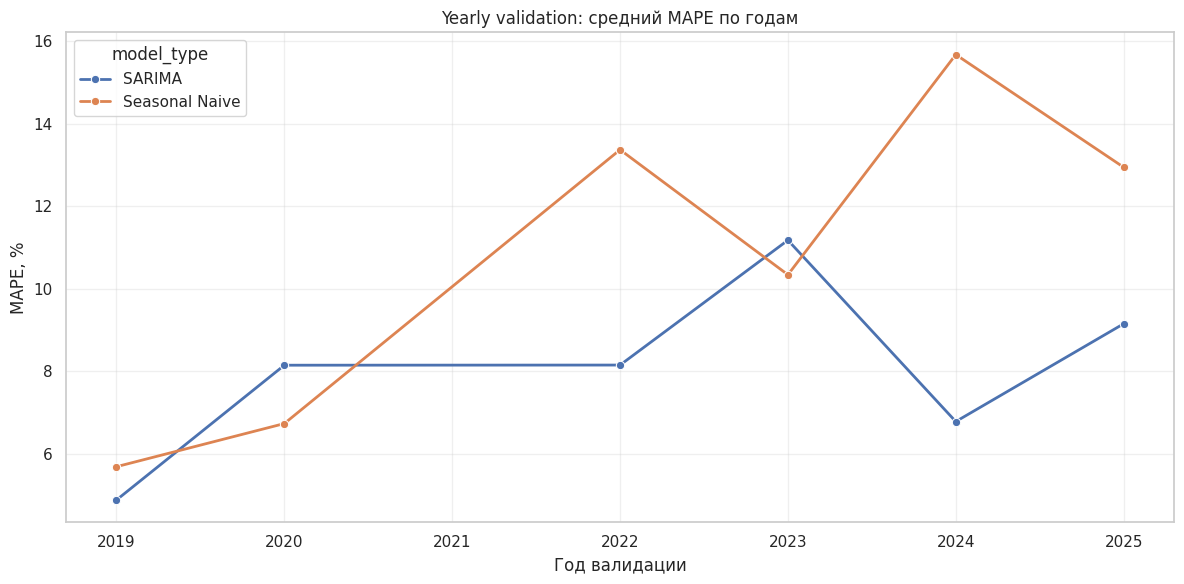

In [13]:
plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=yearly_summary,
    x="validation_year",
    y="mean_MAPE",
    hue="model_type",
    marker="o",
    linewidth=2
)

plt.title("Yearly validation: средний MAPE по годам")
plt.xlabel("Год валидации")
plt.ylabel("MAPE, %")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

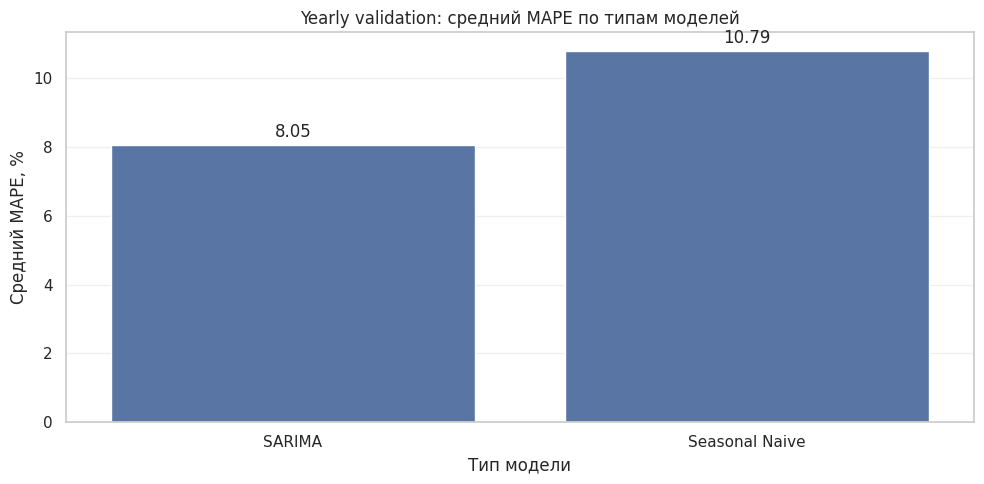

In [14]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=yearly_model_type_summary,
    x="model_type",
    y="mean_MAPE"
)

plt.title("Yearly validation: средний MAPE по типам моделей")
plt.xlabel("Тип модели")
plt.ylabel("Средний MAPE, %")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.tight_layout()
plt.show()

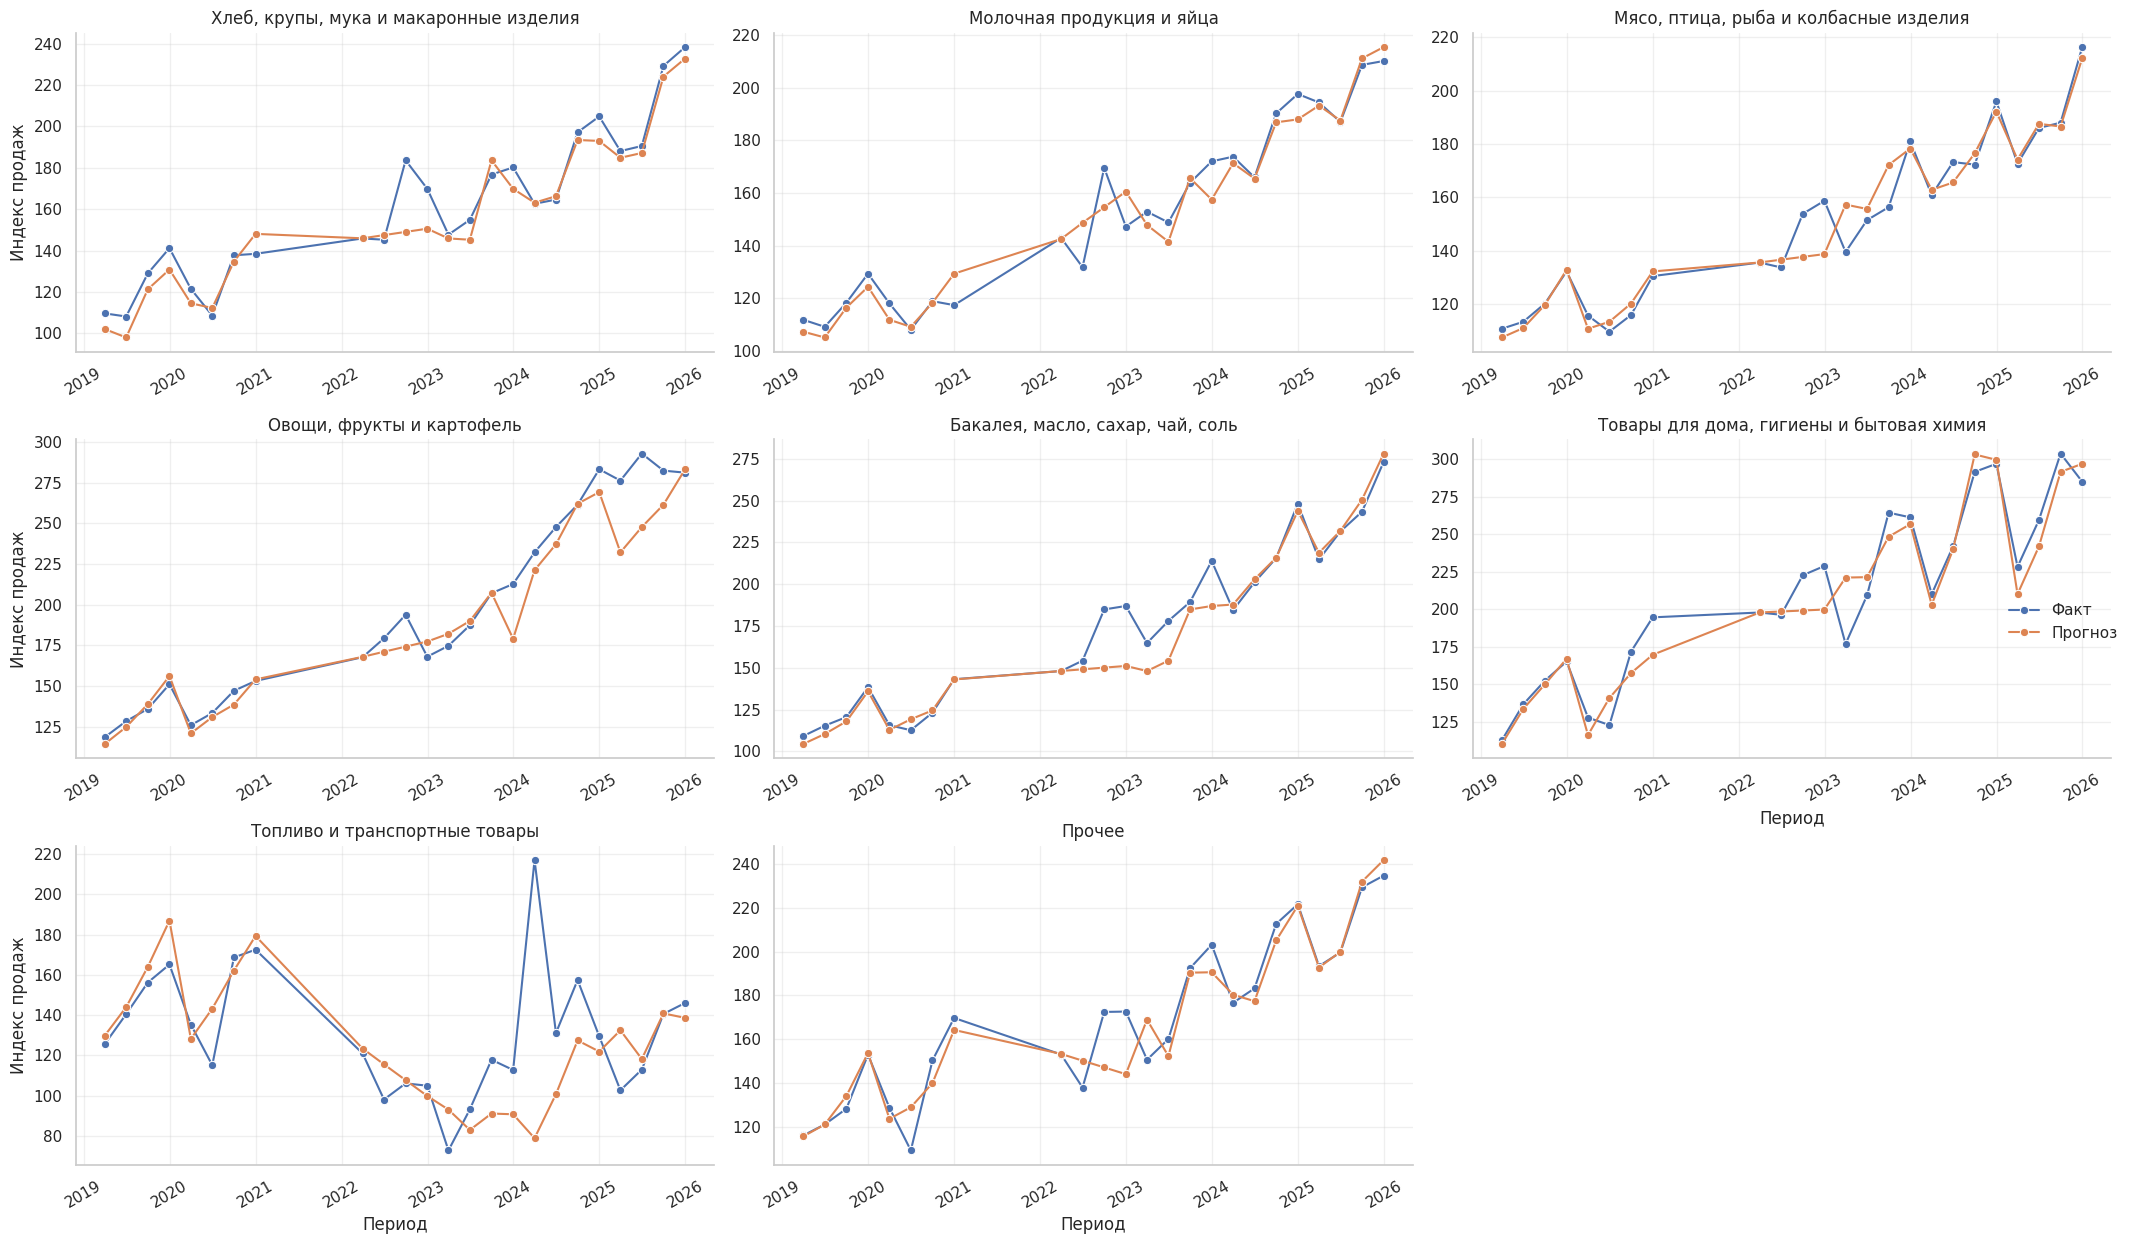

In [15]:
best_keys = best_by_category_year[
    [
        "validation_year",
        "product_group_code",
        "model"
    ]
].copy()

best_yearly_predictions = yearly_cv_predictions_df.merge(
    best_keys,
    on=[
        "validation_year",
        "product_group_code",
        "model"
    ],
    how="inner"
)

plot_best_yearly = pd.concat(
    [
        best_yearly_predictions[
            [
                "period_end",
                "validation_year",
                "product_group_name",
                "y"
            ]
        ].rename(columns={"y": "value"}).assign(series="Факт"),
        best_yearly_predictions[
            [
                "period_end",
                "validation_year",
                "product_group_name",
                "yhat"
            ]
        ].rename(columns={"yhat": "value"}).assign(series="Прогноз")
    ],
    ignore_index=True
)

g = sns.FacetGrid(
    plot_best_yearly,
    col="product_group_name",
    col_wrap=3,
    height=4.2,
    aspect=1.6,
    hue="series",
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="period_end",
    y="value",
    marker="o"
)

g.add_legend(title="")
g.set_axis_labels("Период", "Индекс продаж")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis="x", labelrotation=30)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()